# Risk-Model Evaluation: Does Gaussian VaR Survive Backtesting?

**Question:** three standard methods -- Historical, Parametric (Gaussian), and
Monte Carlo -- are used to estimate Value at Risk (VaR) and Expected Shortfall
(ES) on a diversified equity portfolio. All three make the same *promise*
("you won't lose more than X% on 99 out of 100 days"). Do their promises
actually hold up when checked against data none of them saw while being
built?

**Roadmap:** data & method, a descriptive comparison of the three methods,
then the real test -- a statistical backtest (Kupiec's proportion-of-failures
test and Christoffersen's independence test) over a temporal hold-out set --
and an honest verdict.

All calculation logic lives in `src/`; this notebook only calls it and
narrates the result.

## 1. Data & Method

**Portfolio:** five liquid, sector-diverse US large-caps -- AAPL (tech), JPM
(financials), XOM (energy), JNJ (healthcare), PG (consumer staples) -- equal
weighted (20% each), daily, split/dividend-adjusted prices from Yahoo Finance.
Weights are rebalanced back to 20/20/20/20/20 every day (the standard
simplifying assumption in VaR backtesting literature).

**Why multi-asset, multi-sector:** with a single asset, Monte Carlo VaR
collapses into the same closed-form math as Parametric VaR -- there's nothing
for simulation to demonstrate. A multi-asset portfolio needs a real
covariance structure, and sector diversity keeps correlations moderate
rather than near 1, which is what makes Historical and Parametric VaR
diverge visibly later.

In [1]:
import sys
sys.path.insert(0, "..")

%matplotlib inline
import pandas as pd
import numpy as np

from src.data import (
    fetch_prices, compute_returns, compute_portfolio_returns, train_test_split_returns,
)
from src.var_models import HistoricalVaR, ParametricVaR, MonteCarloVaR
from src.expected_shortfall import historical_es, parametric_es, monte_carlo_es
from src.backtests import count_violations, backtest_var
from src.plots import plot_cumulative_growth, plot_monte_carlo_outcomes, plot_var_backtest

In [2]:
prices = fetch_prices()
asset_returns = compute_returns(prices)
portfolio_returns = compute_portfolio_returns(asset_returns)

print(f"{len(portfolio_returns)} trading days, "
      f"{portfolio_returns.index.min().date()} to {portfolio_returns.index.max().date()}")
print(f"Annualized volatility: {portfolio_returns.std() * np.sqrt(252):.2%}")

3901 trading days, 2011-01-04 to 2026-07-10
Annualized volatility: 16.29%


Data-quality sanity check before anything else: cumulative growth of $1 in
each stock and in the portfolio. No gaps, no impossible one-day jumps from
an unadjusted split, and the portfolio line should sit sensibly among its
constituents.

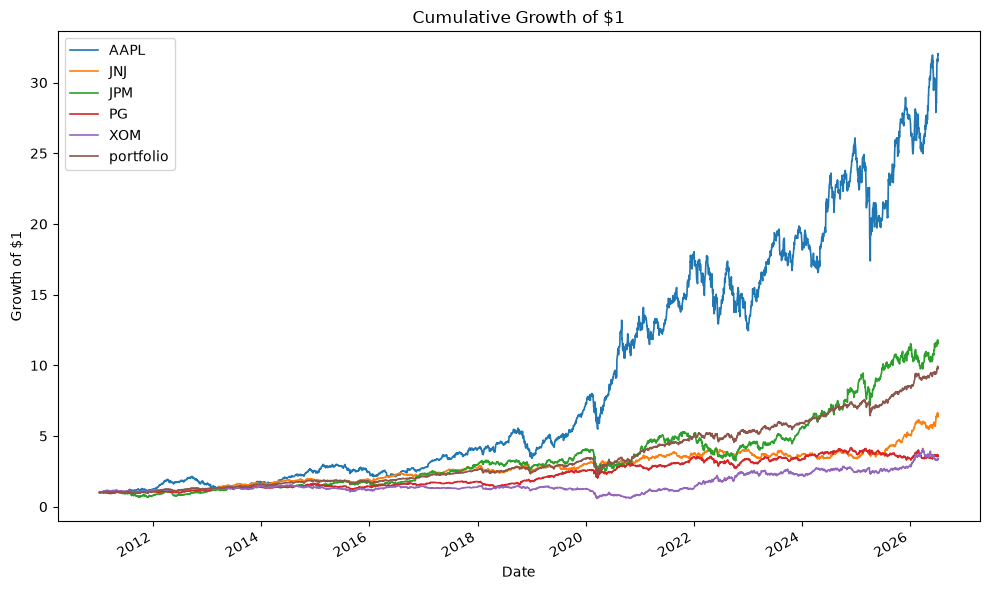

In [3]:
plot_cumulative_growth(asset_returns, portfolio_returns);

## 2. VaR & Expected Shortfall: How Do the Three Methods Compare?

Three ways to answer "how bad could tomorrow get":

- **Historical** -- read the worst days straight off the real return sample. No
  distributional assumption, so it can capture fat tails -- but only as far
  as the training window happened to have already seen.
- **Parametric (Gaussian)** -- assume returns are Normal(mu, sigma), solve for
  the threshold in closed form. Fast, smooth, and only as correct as the
  Normal assumption -- which is exactly what's being tested here.
- **Monte Carlo** -- simulate 100,000 draws from that *same* Normal(mu, sigma)
  and read the empirical quantile off the simulated sample instead of solving
  it analytically. It should converge to the Parametric answer as the
  simulation size grows; the point is demonstrating the technique on a single
  aggregated return series, not adding independent information here.

Expected Shortfall goes one step further than VaR: instead of just the
threshold, it's the *average loss given* you're already past it -- and unlike
VaR, ES is a coherent risk measure (it can't violate subadditivity, i.e. it
can never make diversification look like it increased risk), which is why
bank regulation (Basel's FRTB) moved from VaR to ES as the standard.

In [4]:
methods = {
    "Historical": HistoricalVaR(),
    "Parametric": ParametricVaR(),
    "Monte Carlo": MonteCarloVaR(),
}
es_funcs = {
    "Historical": historical_es,
    "Parametric": parametric_es,
    "Monte Carlo": monte_carlo_es,
}

rows = []
for name, model in methods.items():
    model.fit(portfolio_returns)
    for alpha, label in [(0.01, "99%"), (0.05, "95%")]:
        rows.append({
            "Method": name,
            "Confidence": label,
            "VaR": model.calculate(alpha),
            "ES": es_funcs[name](portfolio_returns, alpha),
        })

comparison = pd.DataFrame(rows)
comparison.style.format({"VaR": "{:.2%}", "ES": "{:.2%}"}).hide(axis="index")

Method,Confidence,VaR,ES
Historical,99%,2.91%,4.11%
Historical,95%,1.51%,2.37%
Parametric,99%,2.32%,2.67%
Parametric,95%,1.62%,2.05%
Monte Carlo,99%,2.34%,2.69%
Monte Carlo,95%,1.64%,2.06%


**Two things to notice, both expected from the underlying math:**

Monte Carlo lands within a couple hundredths of a percentage point of
Parametric at both confidence levels -- convergence confirmed on real data,
not just in theory. And Historical VaR/ES exceeds Parametric at 99%, with the
gap *wider* under ES than under VaR (ES is sensitive to how bad the tail
actually gets, not just where it starts) -- an early sign that the Gaussian
assumption may be understating tail risk. This is only a full-sample,
descriptive comparison, though -- not yet a statistical test of anything.
That comes next.

For context, here's what Monte Carlo is actually doing under the hood: 100,000
draws from the fitted Normal(mu, sigma), with the 99% VaR cutoff marked. The
clean bell shape isn't a finding -- it's a reminder that the simulation is
only ever as thin- or fat-tailed as the Gaussian assumption feeding it; it
cannot discover fat tails on its own the way Historical VaR can.

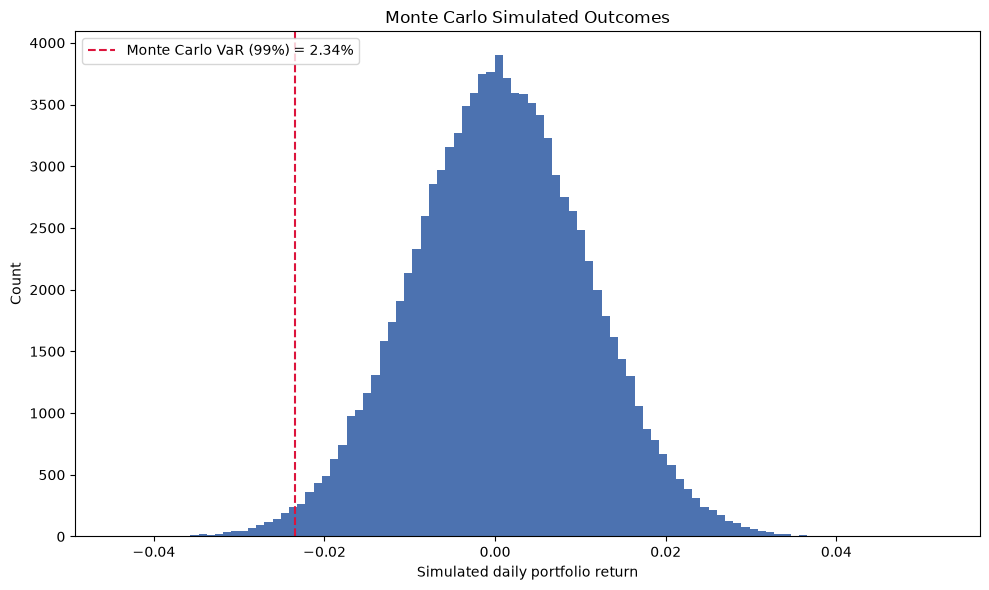

In [5]:
mc_model = MonteCarloVaR().fit(portfolio_returns)
plot_monte_carlo_outcomes(mc_model.simulated_returns, mc_model.calculate(0.01));

## 3. The Real Test: Does the Promise Hold Up Out of Sample?

A descriptive comparison on the full sample can't tell us whether a method is
actually *right* -- only whether the three methods disagree. To test that, we
split the data **in time order, never shuffled**: the first 70% ("train")
is all each model gets to see while forming its promise; the last 30%
("test") checks whether that frozen promise held up on days the model never
saw. Letting a model peek at the test period before promising would be
grading your own exam after seeing the answer key -- lookahead bias, the one
mistake this entire pipeline is built to avoid.

The split is static, not rolling: each model is fit once on train and its
threshold held fixed through the whole test window. Re-estimating partway
through would edge toward time-varying volatility modeling (EWMA/GARCH),
which is outside this project's scope by design.

Two statistical tests are run on the resulting violation series (a "1" on
any test day the actual loss broke the promised threshold):

- **Kupiec's proportion-of-failures test** -- checks only the *count* of
  violations against the promised rate.
- **Christoffersen's independence test** -- checks whether violations
  *cluster* in time. A model can have exactly the right violation count and
  still be broken if all of them hit during the same crash week -- Kupiec
  alone can't see that.
- **Conditional coverage** -- Christoffersen's combined statistic testing
  both properties jointly, at a stricter combined threshold.

A test "passes" at the 5% significance level conventionally used in both the
original papers and industry practice.

In [6]:
train, test = train_test_split_returns(portfolio_returns, train_fraction=0.7)
print(f"Train: {len(train)} days ({train.index.min().date()} to {train.index.max().date()})")
print(f"Test:  {len(test)} days ({test.index.min().date()} to {test.index.max().date()})")

results = []
for name, model in methods.items():
    model.fit(train)
    for alpha, label in [(0.01, "99%"), (0.05, "95%")]:
        var_threshold = model.calculate(alpha)
        row = backtest_var(test, var_threshold, alpha, significance=0.05)
        row.update({"Method": name, "Confidence": label, "VaR": var_threshold})
        results.append(row)

results_df = pd.DataFrame(results)
display_cols = ["Method", "Confidence", "VaR", "n_violations", "expected_violations",
                 "kupiec_p_value", "kupiec_pass", "christoffersen_p_value",
                 "christoffersen_pass", "conditional_coverage_p_value", "conditional_coverage_pass"]

table = results_df[display_cols].copy()
for col in ["kupiec_pass", "christoffersen_pass", "conditional_coverage_pass"]:
    table[col] = table[col].map({True: "PASS", False: "FAIL"})

table.style.format({
    "VaR": "{:.2%}",
    "expected_violations": "{:.1f}",
    "kupiec_p_value": "{:.3f}",
    "christoffersen_p_value": "{:.3f}",
    "conditional_coverage_p_value": "{:.3f}",
}).hide(axis="index")

Train: 2730 days (2011-01-04 to 2021-11-05)
Test:  1171 days (2021-11-08 to 2026-07-10)


Method,Confidence,VaR,n_violations,expected_violations,kupiec_p_value,kupiec_pass,christoffersen_p_value,christoffersen_pass,conditional_coverage_p_value,conditional_coverage_pass
Historical,99%,3.03%,4,11.7,0.009,FAIL,0.008,FAIL,0.001,FAIL
Historical,95%,1.57%,38,58.6,0.003,FAIL,0.038,FAIL,0.002,FAIL
Parametric,99%,2.44%,10,11.7,0.606,PASS,0.071,PASS,0.171,PASS
Parametric,95%,1.71%,33,58.6,0.000,FAIL,0.013,FAIL,0.000,FAIL
Monte Carlo,99%,2.46%,10,11.7,0.606,PASS,0.071,PASS,0.171,PASS
Monte Carlo,95%,1.72%,32,58.6,0.000,FAIL,0.010,FAIL,0.000,FAIL


**The honest finding -- not the one assumed going in.** The project's
governing rule is to report what fails, not engineer an impressive result;
here's what actually happened. Every model failed at 95%, and Historical
specifically failed at 99% while Parametric and Monte Carlo passed -- and
every single failure is a model being **too conservative** (too few
violations), not too aggressive. The textbook "Gaussian underestimates tail
risk" story did not show up cleanly in this split.

**Most likely mechanism:** the training window (2011-2021) contains the
March 2020 COVID crash, one of the most extreme volatility events on record.
Historical VaR bakes that crash directly into its empirical 99% quantile,
which is why its threshold is actually *wider* than Parametric's -- the
opposite of the usual "Gaussian is too narrow" framing. That wide threshold
then gets checked against 2021-2026, a period that hasn't (yet) repeated
anything as extreme, so violations came in far below the promised rate. At
95%, all three methods under-violate similarly, suggesting the whole
training-period volatility level was COVID-inflated relative to the
test-period reality, independent of method.

This is arguably a *better* result to report than the textbook one would
have been: it's the backtest doing its actual job -- catching a real
miscalibration (stale, crash-inflated training volatility) instead of
confirming a scripted preconception.

### Seeing it, not just reading the numbers

The two charts below make the table concrete: actual test-period returns,
the frozen VaR threshold as a dashed line, and every violation marked. (Monte
Carlo's version is omitted -- it is visually indistinguishable from
Parametric's, the same convergence property already shown in Section 2.)

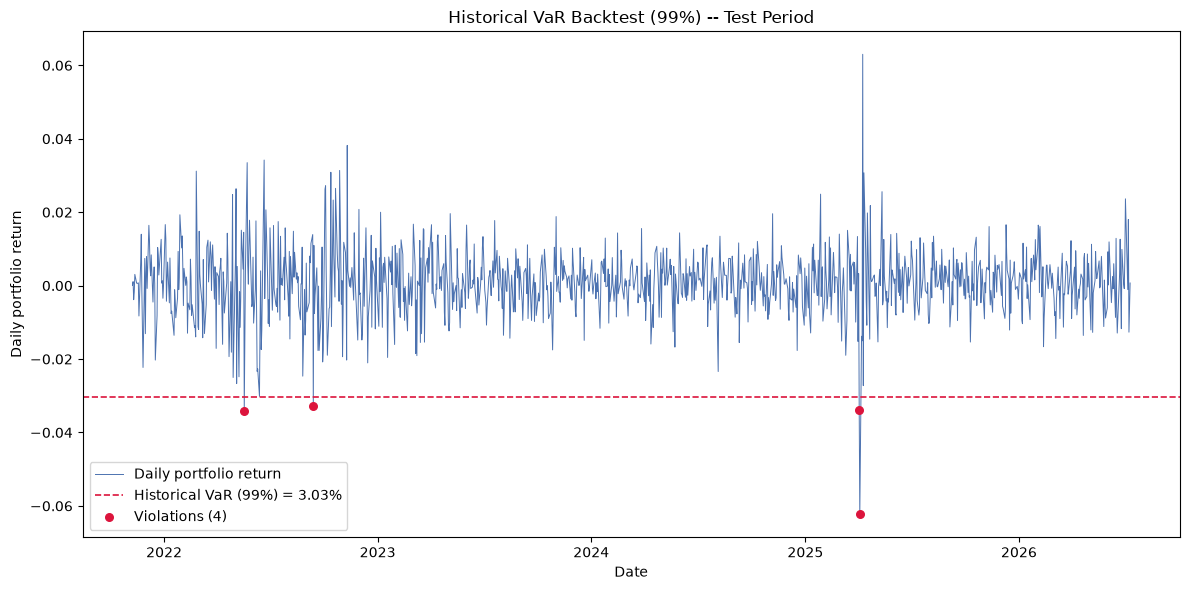

In [7]:
hist_model = HistoricalVaR().fit(train)
hist_var = hist_model.calculate(0.01)
hist_violations = count_violations(test, hist_var)
plot_var_backtest(test, hist_var, hist_violations, "Historical", "99%");

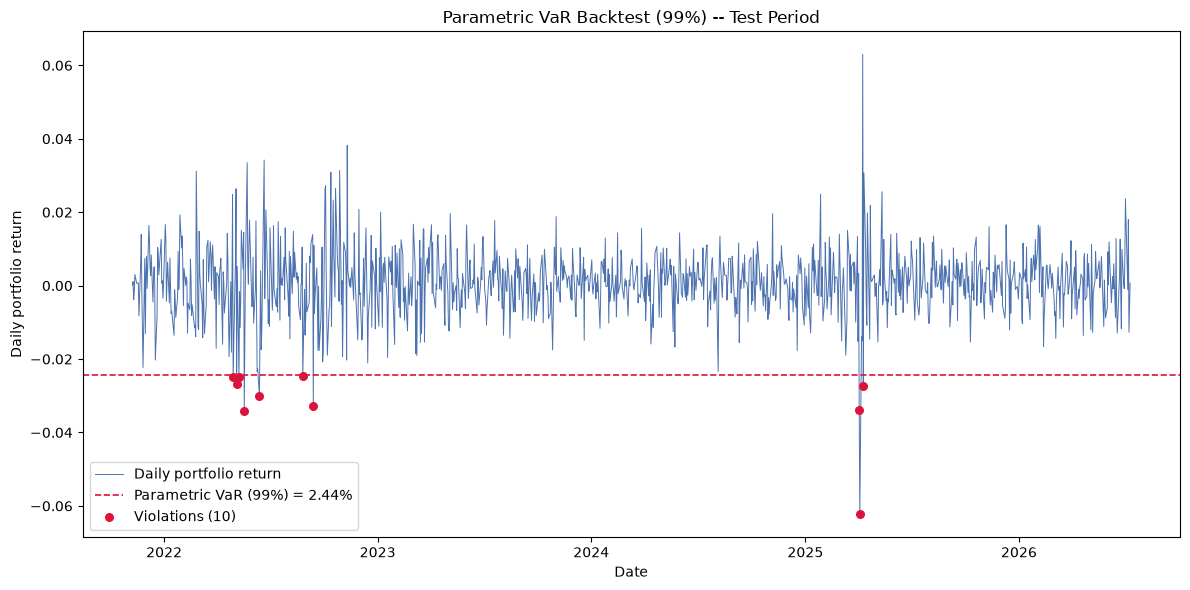

In [8]:
param_model = ParametricVaR().fit(train)
param_var = param_model.calculate(0.01)
param_violations = count_violations(test, param_var)
plot_var_backtest(test, param_var, param_violations, "Parametric", "99%");

Something the table alone doesn't make obvious: violations aren't scattered
randomly across the ~4.7-year test window -- they cluster into two episodes,
a tight group in early/mid 2022 (the rate-hike-driven selloff) and one
dramatic single day around mid-2025 (roughly -6.3%, the worst day in the
whole test period). That clustering is exactly what Christoffersen's test is
built to detect, and it's why Parametric/Monte Carlo's Christoffersen
p-value (0.071) is less reassuring than it looks in isolation -- it sits
uncomfortably close to the 0.05 cutoff precisely because the violations
really are clustered, just not quite enough to formally reject at this
significance level.

## 4. Limitations

Stated plainly rather than glossed over:

- **Split sensitivity.** This result is partly an artifact of *where* the
  70/30 split happens to fall relative to the COVID crash (just inside
  training, not test). It is not a universal law about Historical vs.
  Parametric VaR -- a different split point could tell a different story.
- **Static, not rolling, VaR.** Each model's threshold is frozen at the
  point of the split rather than re-estimated through the test window. This
  keeps the project inside its stated toolkit (no time-varying volatility
  methods), but it also means the models never get to "notice" that the
  test period turned out calmer than training.
- **Expected Shortfall is not statistically backtested here.** Backtesting
  ES properly (e.g. the Acerbi-Szekely test) needs machinery outside this
  project's toolkit and roadmap. ES's role in this project is the coherence
  argument in Section 2, not a claim validated the way VaR is in Section 3.
- **Single portfolio, single historical window.** Five large-cap US equities,
  2011-2026. The finding is about this portfolio and this backtest, not a
  general verdict on any VaR method.

## 5. Conclusion

The original hypothesis going into this project was the textbook one: that
Gaussian (Parametric) VaR would underestimate tail risk and fail its
backtest, while Historical VaR, unconstrained by any distributional
assumption, would hold up better. That is not what happened. In this
specific 70/30 split of this specific portfolio, **Parametric and Monte
Carlo VaR passed the 99% backtest and Historical VaR failed it** -- and every
model that failed did so by being too cautious, not too reckless, most
likely because the training window absorbed an unusually extreme event
(the March 2020 crash) that the test window did not repeat.

The value of this project was never in confirming a specific textbook
result -- it was in building a pipeline rigorous enough to find out either
way, and reporting the answer honestly even when it wasn't the one assumed
at the outset. A risk model's promise is only worth as much as the backtest
that checks it; here, checking it is what actually mattered.